<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="https://www.uoc.edu/portal/_resources/common/imatges/sala_de_premsa/noticies/2016/202-nova-marca-uoc.jpg", align="left" width="380" height="120">

</div>
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">M2.893 · Anàlisi de textos</p>
<p style="margin: 0; text-align:right;">Màster en Ciència de Dades Aplicada</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudis d'Informàtica, Multimèdia i Telecomunicacions</p>
</div>
</div>
<div style="width: 100%; clear: both;">
<div style="width:100%;">&nbsp;</div>

# PRA 2: Deep Learning per a l'anàlisi de textos

En aquesta pràctica revisarem i aplicarem els coneixements apresos en el últims mòduls del curs. Treballarem els següents temes:

1. **Traducció automàtica(TA)**: amb 'custom embeddings' i amb 'embeddings preentrenats'.
2. **NER i NEL**: Entrenament de models de detecció d'entitats anomenades (NER), detecció i classificació.  Detección de entitats anomenades basant-nos en Wikidata aplicada a NER.

També inclourem altres temes transversals treballats al llarg de l'assignatura.

#0 Connexió amb 'Google Drive'

Aquesta secció realitza la connexió amb `drive` i estableix el directori arrel en el que s'emmagatzemem tots els recursos necessaris per a executar el notebook.

El 'path' de treball s'emmagatzema a la variable `my_path_pra2`.

**Estructura de directoris**

S'estableix el directori arrel segons la variable `my_path_pra2`. En aquest directori s'emmagatzemaran els arxius i directoris necessaris per a l'execució del notebook. L'estructura i continguts són els següents:

    * directori `TA` on s'emmagatzemen les dades i recursos per a realitzar la traducció automàtica; conté:
      * glove.42B.300d.txt    # carregat per l'usuari.
      * nld.txt      # carregat per l'usuari.
      * directori `model` on s'emmagatzemen els *best model* de l'entrenament dels models de traducció automàtica:
        * model_ta_en_de-g.keras    # 'best model' generat per l'entrenament de TA amb 'embeddings' preentrenats
        * model_ta_en_de.keras      # 'best model' generat por l'entrenament de TA amb 'custom' embeddings.
    * directori `NER` amb els arxius necessaris per a la pràctica NER:
        * Directori `output_ner`   on s'hi trobaran els *model-best* y *model-last* entrenats per aquest notebook.
        * config.cfg    # carregat per l'usuari.
        * test.txt      # carregat per l'usuari.
        * test.spacy    # Conversió de test.txt al format spacy
        * train.txt     # carregat per l'usuari.
        * train.spacy   # Conversió de train.txt al format spacy
        * valid.txt     # carregat per l'usuari.
        * valid.spacy   # Conversió de valid.txt al format spacy



**Execució d'aquest notebook en un entorno no `Colab`.**

Si no s'executa aquest notebook a Google Colab, substituir aquesta secció (*0. Connexió amb Google Drive*) per la corresponent a la configuració desitjada, tenint en compte que cal disposar d'una GPU amb, almenys, 15 GB de memòria RAM.

**Execució d'aquest notebook en un entorno `Colab`.**

Si s'executa aquest notebook a Colab, cal utilitzar al menys una GPU del tipus 'T4 GPU' o superior. Tenir en compte que si s'utilitza el servei gratuït de Colab, aquestes GPU no estan disponibles permanentment i, quan ho estan, només se'n pot disposar mentre duren les 'compute units' assignades a l'usuari o per límits de disponibilitat de GPUs de Google. Quan no hi ha disponibilitat, cal esperar a una nova assignació. Google no publica el mètode d'assignació o els [terminis de disposició](https://research.google.com/colaboratory/faq.html#usage-limits) de GPUs. Consulta a Colab (Opció de menú 'Runtime' >>>> 'View resources') la disponibilitat en cada moment de Compute Units i GPUs.

En tots els casos, aquest notebook pressuposa l'estructura de directoris de treball descrita.

In [1]:
import os

# Accedir a Colab myDrive
from google.colab import drive
drive.mount("/content/drive")

# Establir el directori arrel
my_path_pra2 = "/content/drive/MyDrive/PRA2"

if os.path.exists(my_path_pra2):
    try:
        os.chdir(my_path_pra2)
        print(f"Directori arrel canviat a: '{os.getcwd()}'")
    except Exception as e:
        print(f"Error canviant al directori: '{my_path_pra2}'. Error: {e}")
else:
    print(f"Directori '{my_path_pra2}' no existeix")

Mounted at /content/drive
Directori arrel canviat a: '/content/drive/MyDrive/PRA2'


In [ ]:
# Instal·lació de translate-toolkit per obrir arxius tmx
!pip install translate-toolkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 745.1/745.1 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.4/100.4 kB 10.0 MB/s eta 0:00:00


# 1 Traducció Automàtica (TA) (7 puntos)




En aquesta primera part de la pràctica es demana resoldre els exercicis usant la llibreria **KERAS**.

## 1.1 TA amb Custom Embeddings

L'objectiu d'aquest apartat és entrenar un model de traducció automàtica entre dos idiomes escollits a partir de l'arxiu escollit, seguint els mateixos passos que el notebook de *Machine Translation*.

**Implementació:** Seguint els passos treballats en el notebook de traducció automàtica, implementar i entrenar un model de traducció automàtica, de l'**idioma origen** a l'**idioma destí**.
* En aquest notebook d'exemple s'utilitza com a dimensión de la capa d'embedding (*embedding_vec_length*) el valor de 200. Més endavant, es variarà aquesta dimensió i es revisaran els resultats.
* La longitud de seqüència es determinant en la duració del temps de procés i en el consumo de memoria del processador durant l'entrenament. A Google Colab es pot cancel·lar el programa si es consumeix tota la memòria disponible. Provar amb diferents longituds, des de 4 (molt reduïda i, per tant, produirà una qualitat baixa de traducció), fins a longituds més grans (8, 12, 16).

* Finalment, es mostrarà com aplicar el model entrenat amb exemples de l'arxiu de dataset.


### 1.1.1 Preparació de dades

* Primer prepararem les dades seleccionades (tingueu en compte que l'*idioma origen* ha de ser **anglès**), per a que es puguin llegir correctament i tinguin el format adequat per a la pràctica.

**a. Carreguem les dades des de la font seleccionada.**

*Sortides esperades:*
- Longitud del dataset.
- Almenys 3 files de dades que mostrin els textos de l'idioma origen i la respectiva traducció.

In [ ]:
from translate.storage.tmx import tmxfile

# Lectura de l'arxiu en_es.tmx de EUIPO_law
with open("TA/en_es.tmx", "rb") as fin:
  tmx_file = tmxfile(fin, "en", "es")

data = []

for node in tmx_file.unit_iter():
  data.append([node.source, node.target])

# Sortida desitjada
print(f"Longitud del dataset: {len(data)}\nPrimeres 5 files de dades:")
data[:5]

Longitud del dataset: 110385
Primeres 5 files de dades:


[['In Case R 419/2000-2', 'En el asunto R 419/2000-2'],
 ['Cuétara, S.A.', 'Cuétara, S.A.'],
 ['Nacional III, Km. 48 28599 Villarejo de Salvanes (Madrid) Spain Opponent/Appellant represented by Herrero & Asociados, Alcalá 21-6, E-28014 Madrid, Spain versus',
  'Nacional III, Km. 48 28599 Villarejo de Salvanes (Madrid) España Oponente /Parte recurrente representada por Herrero & Asociados, Alcalá 21-6, E-28014 Madrid, España contra'],
 ['Florencio Gómez-Cuétara Fernández Newport, B.H.',
  'Florencio Gómez-Cuétara Fernández Newport, B.H.'],
 ['Dyrberg (Member) Registrar: E.', 'Dyrberg (Miembro) Secretario: E.']]

**b. Preprocessar les dades, per a eliminar la puntuació i convertir a minúscula.**

En primer lloc s'elimina tot tipus de signes de puntuació presents al text.

In [ ]:
# Eliminació de signes de puntuació
data = [[sentence.lower() for sentence in pair] for pair in data]
punct = '".,;:-()!?‘’“”–/'
data = [[word.translate(str.maketrans('', '', punct)) for word in pair] for pair in data]

In [ ]:
data[:8]

[['in case r 41920002', 'en el asunto r 41920002'],
 ['cuétara sa', 'cuétara sa'],
 ['nacional iii km 48 28599 villarejo de salvanes madrid spain opponentappellant represented by herrero & asociados alcalá 216 e28014 madrid spain versus',
  'nacional iii km 48 28599 villarejo de salvanes madrid españa oponente parte recurrente representada por herrero & asociados alcalá 216 e28014 madrid españa contra'],
 ['florencio gómezcuétara fernández newport bh',
  'florencio gómezcuétara fernández newport bh'],
 ['dyrberg member registrar e', 'dyrberg miembro secretario e'],
 ['for the following goods class 29  meat fish poultry and game meat extracts preserved dried and cooked fruits and vegetables jellies jams fruit sauces eggs milk and milk products edible oils and fats potato crisps',
  'para distinguir clase 29  carne pescado aves y caza extractos de carne frutas y legumbres en conserva secas y cocidas jaleas mermeladas compotas huevos leche y productos lácteos aceites y grasas comestibles 

Com es pot veure a l'última parella, al text hi queden els tabuladors "\t". Els eliminem.

In [ ]:
# Eliminació de tab
data = [[sentence.replace("\t", "") for sentence in pair] for pair in data]

In [ ]:
data[7]

['registered trade marks nos 440 970 and 1 735 549 both claim the colours white and red 4 the opponent based its opposition on all the goods of the earlier registrations and directed it against all the goods of the community trade mark application 5 on 20 march 2000 the opposition division of the office gave decision no 5172000 the contested decision in which it upheld the opposition for many of the goods and services against which it was directed and consequently rejected the community trade mark application in respect of these',
 'registros nº 440970 y 1735549 ambos reivindican los colores blanco y rojo 4 la oponente basó su oposición en todos los productos de los registros anteriores y se dirigió contra todos los productos de la solicitud de marca comunitaria 5 el 20 de marzo de 2000 la división de oposición de la oficina dictó la resolución nº 5172000 en lo sucesivo la resolución impugnada por la cual estimó la oposición para gran parte de los productos y servicios contra los que s

Mostrem, doncs, el conjunt de dades normalitzat:

In [ ]:
data[:10]

[['in case r 41920002', 'en el asunto r 41920002'],
 ['cuétara sa', 'cuétara sa'],
 ['nacional iii km 48 28599 villarejo de salvanes madrid spain opponentappellant represented by herrero & asociados alcalá 216 e28014 madrid spain versus',
  'nacional iii km 48 28599 villarejo de salvanes madrid españa oponente parte recurrente representada por herrero & asociados alcalá 216 e28014 madrid españa contra'],
 ['florencio gómezcuétara fernández newport bh',
  'florencio gómezcuétara fernández newport bh'],
 ['dyrberg member registrar e', 'dyrberg miembro secretario e'],
 ['for the following goods class 29  meat fish poultry and game meat extracts preserved dried and cooked fruits and vegetables jellies jams fruit sauces eggs milk and milk products edible oils and fats potato crisps',
  'para distinguir clase 29  carne pescado aves y caza extractos de carne frutas y legumbres en conserva secas y cocidas jaleas mermeladas compotas huevos leche y productos lácteos aceites y grasas comestibles 

**c. Per a tenir una idea de la mida dels textos a analitzar, en funció de la quantitat de paraules, visualitzem les dades resultants amb un histograma.**

*Sortida esperada:* Dos histogramas que mostrin la quantitat de tokens dels textos del corpus, un per als vectors de l'idioma origen i l'altre per als de destí.

In [ ]:
# Separació dels textos per idiomes
text_EN = []
text_ES = []

for pair in data:
    text_EN.append(pair[0])
    text_ES.append(pair[1])

In [ ]:
# Alguns textos en anglès
text_EN[:6]

['in case r 41920002',
 'cuétara sa',
 'nacional iii km 48 28599 villarejo de salvanes madrid spain opponentappellant represented by herrero & asociados alcalá 216 e28014 madrid spain versus',
 'florencio gómezcuétara fernández newport bh',
 'dyrberg member registrar e',
 'for the following goods class 29  meat fish poultry and game meat extracts preserved dried and cooked fruits and vegetables jellies jams fruit sauces eggs milk and milk products edible oils and fats potato crisps']

In [ ]:
# Alguns textos en espanyol
text_ES[:6]

['en el asunto r 41920002',
 'cuétara sa',
 'nacional iii km 48 28599 villarejo de salvanes madrid españa oponente parte recurrente representada por herrero & asociados alcalá 216 e28014 madrid españa contra',
 'florencio gómezcuétara fernández newport bh',
 'dyrberg miembro secretario e',
 'para distinguir clase 29  carne pescado aves y caza extractos de carne frutas y legumbres en conserva secas y cocidas jaleas mermeladas compotas huevos leche y productos lácteos aceites y grasas comestibles patatas chips patatas fritas a la inglesa']

In [ ]:
import nltk
from nltk.tokenize import word_tokenize
nltk.download("punkt_tab")

# Tokenització dels textos en anglès
tokenized_EN = [word_tokenize(sentence) for sentence in text_EN]
print(tokenized_EN[:5])

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


[['in', 'case', 'r', '41920002'], ['cuétara', 'sa'], ['nacional', 'iii', 'km', '48', '28599', 'villarejo', 'de', 'salvanes', 'madrid', 'spain', 'opponentappellant', 'represented', 'by', 'herrero', '&', 'asociados', 'alcalá', '216', 'e28014', 'madrid', 'spain', 'versus'], ['florencio', 'gómezcuétara', 'fernández', 'newport', 'bh'], ['dyrberg', 'member', 'registrar', 'e']]


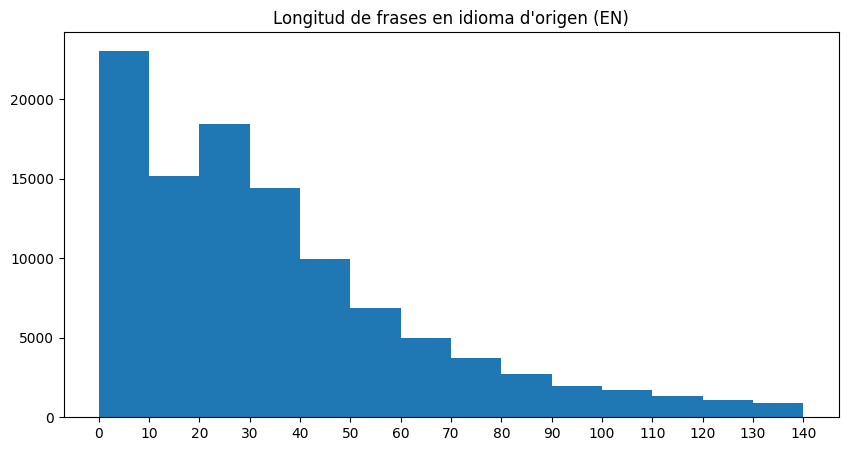

In [ ]:
import matplotlib.pyplot as plt

# Recompte de longitud de frases
EN_count = [len(sentence) for sentence in tokenized_EN]

# Definició del recompte de 10 en 10 fins a 150
bins = range(0, 150, 10)

# Histograma
plt.figure(figsize=(10, 5))
plt.hist(EN_count, bins=bins)
plt.xticks(bins)
plt.title("Longitud de frases en idioma d'origen (EN)")
plt.show()

In [ ]:
# Tokenització dels textos en espanyol
tokenized_ES = [word_tokenize(sentence) for sentence in text_ES]
print(tokenized_ES[:5])

[['en', 'el', 'asunto', 'r', '41920002'], ['cuétara', 'sa'], ['nacional', 'iii', 'km', '48', '28599', 'villarejo', 'de', 'salvanes', 'madrid', 'españa', 'oponente', 'parte', 'recurrente', 'representada', 'por', 'herrero', '&', 'asociados', 'alcalá', '216', 'e28014', 'madrid', 'españa', 'contra'], ['florencio', 'gómezcuétara', 'fernández', 'newport', 'bh'], ['dyrberg', 'miembro', 'secretario', 'e']]


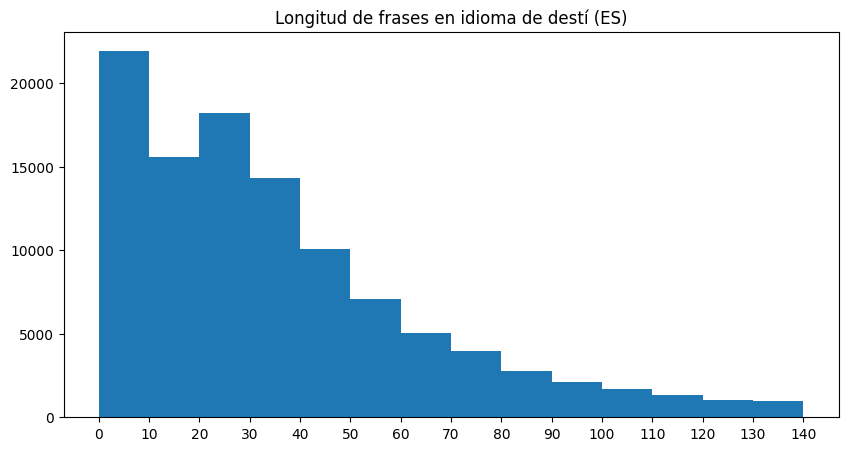

In [ ]:
# Recompte de longitud de frases
ES_count = [len(sentence) for sentence in tokenized_ES]

# Definició del recompte de 10 en 10 fins a 150
bins = range(0, 150, 10)

# Histograma
plt.figure(figsize=(10, 5))
plt.hist(ES_count, bins=bins)
plt.xticks(bins)
plt.title("Longitud de frases en idioma de destí (ES)")
plt.show()

Per a la definició dels models, necessitem instal·lar *keras* i *tensorflow*.

**d. Calculem el vocabulari tant el de l'idioma origen, com el de l'idioma destí, i imprimim el nombre de paraules**.

*Resultat esperat:* Es visualitzaran dos nombres, el de paraules del vocabulari de l'idioma origen i el de destí, després d'haver aplicat el preprocessament i la tokenització.

In [ ]:
import tensorflow as tf

# Tokenitzador
def tokenization(sentences):
    tokenizer = tf.keras.preprocessing.text.Tokenizer()
    tokenizer.fit_on_texts(sentences)
    return tokenizer

# Vocabularis
en_tokenizer = tokenization(text_EN)
es_tokenizer = tokenization(text_ES)

# Mida dels vocabularis
en_vocab_size = len(en_tokenizer.word_index) + 1
es_vocab_size = len(es_tokenizer.word_index) + 1

# Resultats
print(f"Vocabulari de l'idioma d'origen (EN): {en_vocab_size}")
print(f"Vocabulari de l'idioma de destí (ES): {es_vocab_size}")

Vocabulari de l'idioma d'origen (EN): 48172
Vocabulari de l'idioma de destí (ES): 55551


**e. Separem els conjunts d'entrenament per idioma i els codifiquem.**

En aquest pas, se separen les dades en dos conjunts: un per a entrenament (*train*) i l'altre per a prova (*test*), utilitzant una divisió del 80% per a entrenament i 20% per a prova.

*Sortida esperada:* tres primeres files del dataset d'entrenament *train*.


In [ ]:
from sklearn.model_selection import train_test_split

# Generació de conjunts d'entrenament i test
train, test = train_test_split(data, test_size=0.2, random_state = 12)

In [ ]:
# 3 primeres instàncies d'entrenament
train[:3]

[['on the contrary in the present case no evidence in favour of the existence of an earlier right was produced before the opposition division and the opponent did not even reply to the request for it or apply for an extension of the time limit',
  'por el contrario en el caso presente no se presentó ningún elemento a favor de la existencia del derecho anterior ante la división de oposición el oponente ni siquiera respondió al requerimiento de ésta y tampoco solicitó una prórroga del plazo'],
 ['lópez fernández de corre s', 'lópez fernández de corres'],
 ['34 under article 152a ctmr the use of a community trade mark in a form differing in elements which do not alter the distinctive character of the mark in the form in which it was registered is considered to constitute use of the mark',
  '34 con arreglo al artículo 15 apartado 2 letra a del rmc tendrá la consideración de uso de la marca comunitaria su empleo «en una forma que difiera en elementos que no alteren el carácter distintivo d

**f. Definir i aplicar una funció per a codificar les seqüències**

En aquest pas, els dos conjunts de dades creats en el punt anterior,  seran codificats usant **tokenització** i un procés de **padding** per a assegurar que totes les seqüències d'un mateix idioma tinguin la mateixa longitud.

**Important:** Per a dur a terme un primer experiment, *depenent de la capacitat de processament disponible de cadascú*, se suggereix ajustar el valor del paràmetre **longitud de seqüència*, *fins a trobar el valor més alt possible que permeti entrenar el model encoder-decoder en un temps acceptable.*

El paràmetre **longitud de seqüència** té un impacte important en l'entrenament del model. Un valor alt permet al model capturar més context de les frases, la qual cosa és crucial per a traduir correctament oracions complexes; no obstant això, si la longitud és massa curta, el model pot truncar frases importants, perdent informació clau.

Uso de memoria y eficiencia computacional:

Majors longituds requereixen més memòria, ja que el model defineix matrius més grans per a representar les seqüències. Mentre que longituds curtes són més eficients en termes de recursos, però poden sacrificar precisió si les oracions reals excedeixen aquest límit amb freqüència.

Finalment, en traducció automàtica, les longituds de les seqüències en l'idioma origen i destí no sempre han de ser iguals (per exemple, una oració en anglès pot ser més curta que la seva equivalent en alemany).

Considerant tot l'anterior, si es disposa d'infraestructura amb GPU, se suggereix iniciar amb un valor máximo de 12 (o proper) i mínim de 4. A la cel·la de codi que segueix, es proposa iniciar amb un valor intermedi de 8, però aquest valor pot ser ajustat.

Si durant l'entrenament, es produeixen problemes (per limitació d'infraestructura), es podrà tornar a aquest pas per a fixar el valor mínim de 4 per a la longitud de seqüència de tots dos idiomes (tot i que els resultats de la traducció no seran de qualitat)

**Sortida esperada:** Mida de cada arxiu i mostra de les tres primeres seqüències codificades de l'arxiu d'entrenament.

In [ ]:
from keras.preprocessing.sequence import pad_sequences
import numpy as np

# Longitud de seqüència
max_text_length = 8

# Funció per codificar seqüències
def encode_sequences(tokenizer, length, lines):
    seq = tokenizer.texts_to_sequences(lines)
    seq = pad_sequences(seq, maxlen=length, padding="post")
    return seq

# Codificació de conjunts d'entrenament i test
X_train = encode_sequences(en_tokenizer, max_text_length, [row[0] for row in train])
y_train = encode_sequences(es_tokenizer, max_text_length, [row[1] for row in train])
X_test = encode_sequences(en_tokenizer, max_text_length, [row[0] for row in test])
y_test = encode_sequences(es_tokenizer, max_text_length, [row[1] for row in test])

In [ ]:
# Mides de X_train, X_test i 3 primeres seqüències de X_train
print(f"Mida de X_train: {X_train.shape}\nMida de X_test: {X_test.shape}\n3 primeres seqüències de X_train:")
X_train[:3]

Mida de X_train: (88308, 8)
Mida de X_test: (22077, 8)
3 primeres seqüències de X_train:


array([[  639,    11,    45,  2013,     2,     1,   267,   953],
       [  423,   818,    76, 13196,   778,     0,     0,     0],
       [    9,   135,     5,   823,    43,     2,     1,    10]],
      dtype=int32)

### 1.1.2 Definició del model encoder-decoder i entrenament (2 punts)

**a. Definim el model *encoder-decoder* basant-nos en el notebook vist a l'assignatura**, i l'instanciem amb una capa d'embedding per a les frases de la **llengua origen** i la dimensió de la última capa com la del vocabulario de la **llengua destí**.

**Important:** Per a la definició del model, considerar els següents paràmetres i valors referencials:

* Com a quantitat de **units** treballar, inicialment, amb el valor de 100. El nombre d'unitats o cel·les de memòria de cada capa LSTM defineix la dimensionalitat de l'espai intern en el que la LSTM processa i representa la informació al llarg del temps; és a dir, és la mida del vector de l'estat ocult *hidden state* i de l'estat de cel·la *cell state* que la LSTN manté per a capturar patrons i dependències de les seqüències d'entrada.

 A major nombre de *units*, augmenta la capacitat del model per a modelar relacions complexes i dependè cies a llarg termini en el text, la qual cosa és clau per a la traducció automàtica, on el context pot comprendre vàries paraules o frases. No obstant això, un valor alt incrementa el nombre de paràmetres i, per tant, requerirà més memòria i temps de càlcul; a més, creix el risc de sobreajustament si les dades d'entrenament no són suficients.

 Per tant, treballarem amb un valor inicial de 100 tot i que l'ideal seria usar un valor superior.

* Longitud dels vectors d'embeddings *embedding_vec_length*: establir-lo en 200; aquest és un valor referencial que podría ser ajustat segons la mida del vocabulario, la complexitat de l'idioma i els recursos disponibles. Més endavant, *exercici 1.1.3* es demanar variar aquest valor.

**Resultat esperat:** s'haurà instanciat un modelo encoder-decoder. Aquest model està dissenyat per a processar i traduir textos de l'**idioma origen** a l'**idioma destí** utilitzant capes d'embedding i LSTM.

*Sortida esperada*: Utilitzar el mètode *mt_model.summary()* per a visualitzar l'estructura i configuració del model, incloent el nombre de paràmetres i la disposició de les capes.

In [ ]:
from keras.models import Model
from keras.layers import Dense, LSTM, Embedding, RepeatVector, TimeDistributed

# Hiperparàmetres
embedding_vec_length = 200
units = 100
out_timesteps = max_text_length

# Model encoder-decoder
def define_mt_model(in_vocab_size, embedding_vec_length, max_text_length, out_timesteps, out_vocab_size):
    inputs = tf.keras.layers.Input(shape=(max_text_length,), name="input_layer")
    x = Embedding(input_dim=in_vocab_size, output_dim=embedding_vec_length, input_length=max_text_length, mask_zero=True)(inputs)
    x = LSTM(units=units, use_cudnn=False)(x)
    x = RepeatVector(out_timesteps)(x)
    x = LSTM(units=units, return_sequences=True)(x)
    outputs = TimeDistributed(Dense(out_vocab_size, activation="softmax"))(x)
    model = Model(inputs, outputs, name="mt_model_func")
    return model

In [ ]:
# Creació del model i resum
mt_model_ESEN_v01 = define_mt_model(en_vocab_size, embedding_vec_length, max_text_length, out_timesteps, es_vocab_size)
mt_model_ESEN_v01.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "mt_model_func"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 8, 200)    │  9,634,400 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 8)         │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 100)       │    120,400 │ embedding_1[0][0… │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_1     │ (None, 8, 100)    │          0 │ lstm_2[0][0]      │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 8, 100)    │     80,400 │ repeat_vector_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 8, 55551)  │  5,610,651 │ lstm_3[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,445,851 (58.92 MB)

 Trainable params: 15,445,851 (58.92 MB)

 Non-trainable params: 0 (0.00 B)

**b. Compilem el model**

**Resultat esperat:** el model compilat i llest per a ser entrenat. S'utilitzarà l'optimitzador *RMSprop* amb una tasa d'aprenentatge de *0.001* i la funció de pèrdua *sparse_categorical_crossentropy*.

In [ ]:
from keras import optimizers

# Optimitzador i learning rate
rms = optimizers.RMSprop(learning_rate=0.001)

# Compilació
mt_model_ESEN_v01.compile(optimizer=rms, loss="sparse_categorical_crossentropy")

**c. Entrenem i guardem el model.**

**Important:** El model pot trigar hores si es disposa de CPU, molt menys amb GPU. Colab permet l'ús de GPU en general, si no se'n fa un ús intensiu i continuat. Per tant, habilitar només la GPU quan es necessiti per a entrenar i predir. Deshabilitar-la (i per tant reiniciar l'entorn) per a executar les cel·les no necessàries per a entrenar.

* Per tant, per a provar el funcionament, recomanem llençar l'entrenament **només amb una època** i comprovar-ne el funcionament. Un cop tenim clar que el sistema funciona, incrementar el valor (per exemple a 50 o 100, depenent de com evoluciona el model amb cada *epoch*)

* Si durant l'entrenament, Colab no pot carregar el model en memòria, recomanem disminuir el valor de **longitud de paraula** a 4 i el nombre de **units** a 128, d'aquesta manera es podrà completar el procés, tot i que, probablement, els resultats no seran bons.

* Revisar el `Notebook d'Exemple`, en el que es proporcionen pautes i guies per a dur un millor control de les execucions quan s'han de realitzar reinicis de sessió o s'exhaureix la memòria.

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Checkpoint del model
filename = "model/mt_model_ENES_v01.keras"
checkpoint = ModelCheckpoint(filename, monitor="val_loss", verbose=1, save_best_only=True, mode="min")

# Entrenament
mt_model_ESEN_v01.fit(X_train, y_train.reshape((y_train.shape[0], y_train.shape[1], 1)), epochs=30, batch_size=128, validation_split=0.2,
             callbacks=checkpoint, verbose=1)

Epoch 1/30
552/552 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 7.8347
Epoch 1: val_loss improved from inf to 6.41619, saving model to model/mt_model_ENES_v01.keras
552/552 ━━━━━━━━━━━━━━━━━━━━ 66s 111ms/step - loss: 7.8330 - val_loss: 6.4162
Epoch 2/30
552/552 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 6.3906
Epoch 2: val_loss improved from 6.41619 to 6.38630, saving model to model/mt_model_ENES_v01.keras
552/552 ━━━━━━━━━━━━━━━━━━━━ 74s 100ms/step - loss: 6.3906 - val_loss: 6.3863
Epoch 3/30
552/552 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 6.3666
Epoch 3: val_loss improved from 6.38630 to 6.37775, saving model to model/mt_model_ENES_v01.keras
552/552 ━━━━━━━━━━━━━━━━━━━━ 82s 101ms/step - loss: 6.3666 - val_loss: 6.3778
Epoch 4/30
552/552 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 6.3521
Epoch 4: val_loss improved from 6.37775 to 6.35180, saving model to model/mt_model_ENES_v01.keras
552/552 ━━━━━━━━━━━━━━━━━━━━ 82s 101ms/step - loss: 6.3521 - val_loss: 6.3518
Epoch 5/30
552/552 ━━━━━━━━━

**d. Generar prediccions.**

Un cop entrenat el model, aplicar el mètode *predict()* a l'arxiu de test per a obtenir les prediccions.

**Suggeriment:** Revisar el `Notebook d'exemple` en el que es proporciona una pauta per a treballar amb un subconjunt de l'arxiu de tex en cas de tenir limitacions durante el procés de predicció.

In [ ]:
from keras.models import load_model

# Selecció del subset de test
X_test_subset = X_test[:100]

# Càrrega del model
mt_model = load_model("model/mt_model_ENES_v01.keras")

# Prediccions
predictions = mt_model.predict(X_test_subset, batch_size=32)
print(predictions[0])

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step
[[3.0024061e-05 3.8520753e-02 3.9810184e-02 ... 4.9983105e-06
  4.8408615e-06 2.5206464e-06]
 [5.1399513e-07 4.5885805e-02 3.7887212e-02 ... 2.8676029e-06
  2.7990945e-06 1.2774032e-06]
 [5.0650220e-07 4.7583140e-02 3.0290792e-02 ... 3.0070555e-06
  2.9404664e-06 1.2997866e-06]
 ...
 [2.5531128e-05 4.7959406e-02 1.4856090e-02 ... 4.4640624e-06
  4.4523190e-06 1.8407479e-06]
 [1.0041914e-04 4.0759668e-02 1.1317862e-02 ... 4.6813161e-06
  4.6981463e-06 1.9083930e-06]
 [2.3721597e-04 3.4531645e-02 1.0097357e-02 ... 4.7915028e-06
  4.8238549e-06 1.9449471e-06]]


**e. Visualització de resultats.**

Visualitzem els resultats de les prediccions amb els valors esperats.

**Resultat esperat:** prediccions traduïdes de les primeres 10 entrades del conjunt de prova. Aquestes prediccions es mostraran amb els textos esperats a efectes de comprovar la bondat de la predicció.

In [ ]:
import pandas as pd

# Prediccions: de codificació a text
index_word_es = {index: word for word, index in es_tokenizer.word_index.items()}
def get_word(n, index_word):
    return index_word_es.get(n, None)

preds_text = []

for i in predictions:
    temp = []
    for j in range(len(i)):
        token_id = np.argmax(i[j])
        t = get_word(token_id, index_word_es)

        if j > 0:
            prev_token_id = np.argmax(i[j - 1])
            if (t == get_word(prev_token_id, index_word_es)) or (t is None):
                temp.append("")
            else:
                temp.append(t)
        else:
            temp.append("" if t is None else t)

    preds_text.append(" ".join(temp))

# y_test_subset: de codificació a text
index_word_en = {index: word for word, index in en_tokenizer.word_index.items()}
y_test_text = []

for seq in y_test:
    words = [index_word_es.get(token, "") for token in seq if token != 0]
    y_test_text.append(" ".join(words))

# Visualització de resultats
pd.set_option("display.max_colwidth", 300)
pred_df = pd.DataFrame({"y_test" : y_test_text[:10], "Predicció" : preds_text[:10]})
pred_df.head(10)

,y_test,Predicció
0,esté registrada desde hace al menos cinco años,que de y
1,la otra parte en el procedimiento de recurso,de recurso
2,superar un nivel bajo o de mera iniciación,de
3,la solicitante debe desestimarse por carecer de fundamento,la de por
4,pues describe el producto que protege la marca,la
5,pronunciando únicamente su elemento dominante y distintivo iap,la marca
6,el territorio relevante para reparación servicios de instalación,de
7,sean compatibles con los de organización de viajes,de
8,nueva línea o gama de la marca anterior,de marca
9,el escrito con los motivos de su recurso,de


f. **Pregunta d'anàlisi:** Depenent dels resultats obtinguts en la predicció (valors reals vs. valors generats), per què creus que no són bons i com creus que poden obtenir-se millors resultats?

**Resposta a la pregunta:**

Els resultats obtinguts no son gens bons, tot i que el model és capaç de traduïr alguns dels mots més comuns com són algunes conjuncions (de, en, que, y), pronoms (la, una) i alguns substantius freqüents dins del vocabulari (marca, recurso).

Per obtenir millors resultats, caldria ajustar alguns dels hiperparàmetres. Al estar treballant amb seqüències tan llargues (la majoria dels textos tenen entre 10 i 70 paraules tant en l'idioma d'origen com en el de destí), augmentar el nombre de neurones pot ser positiu. Per als propers passos, s'augmenta el nombre d'unitats de les capes LSTM a 512. D'altra banda, també s'ampliara la longitud del vector d'embedding a 300. Ara per ara, es mantindrà la longitud de seqüència a 8, per explorar el rendiment de l'entrenament del model i no exhaurir els recursos de memòria i GPU oferts per cada sessió a Google Colab.






### 1.1.3 Experimentació amb diferents resultats (1,5 punts)

En aquest apartat podríem analitzar com afecta a la qualitat de la traducció la variació de diferents paràmetres del model com ara:
* longitud d'embeddings (*embedding_vec_length*),
* longitud de seqüència (*max_text_length*),
* número de units (*units*),
* batch size,
* epochs,
* ...

No obstant això, degut a que no sempre ens trobarem amb GPUs lliures, aquí ens limitarem a experimentar amb els paràmetres:
* *embedding_vec_length* i
* *max_text_length*.

**Important:** durant les execucions, depenent del model i del consum de memòria actual, la predicció pot cancel·lar si s'exhaureix la memòria disponible. En cas de cancel·lació, recarregar el model des de local (veue apartat 1.1.2.2 del `Notebook d'exemple`) i predir només un subconjunt de l'arxiu de test (tot i que en aquest cas no seran vàlides les magnituds de medició de qualitat del sistema)  

A més, suggerim que després de cada entrenament es realitzi una còpia del model entrenat i s'emmagatzemi en local (*'model/...'*) per a, en cas de cancel·lació, no haver de realitzar de nou l'entrenament, associant al nom de la còpia els paràmetres amb els que ha estat entrenat.


**a. Experimentar amb el valor de longitud de embedding** (*embedding_vec_length*)

Analitzar com un increment en la mida dels vectors de embedding afecta al rendiment d'un model de traducció automàtica de **l'idioma origen** a **l'idioma destí**.

**Resultat esperat:** S'imprimirà el resultat que mostri el rendiment del model creat per a diferents mides d'embeddings (inicialment s'ha treballat amb 200, també es podria experimentar amb valors com ara 50 i 300). Cada resultat constarà de la mida de l'embedding seguit d'un **score** que n'indiqui l'efectivitat del model calculat amb *model.evaluate()*.



In [ ]:
from nltk.translate.bleu_score import corpus_bleu

# Pèrdua mitjana
mean_loss = mt_model.evaluate(X_test_subset, y_test[:100])

# Tokenització dels resultats
split_references = [[ref.split()] for ref in y_test_text[:100]]
split_predictions = [pred.split() for pred in preds_text]

# BiLingual Evaluation Understudy
bleu_score = corpus_bleu(split_references, split_predictions)

# Resultats del model mt_model
print("Resultats de mt_model_ENES_v01 (100 unitats)")
print(f"Mida de l'embedding: {embedding_vec_length}")
print(f"Pèrdua mitjana: {mean_loss:.4f}")
print(f"BLEU: {bleu_score:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 4.9425
Resultats de mt_model_ENES_v01 (100 unitats)
Mida de l'embedding: 200
Pèrdua mitjana: 4.7558
BLEU: 0.0142


In [ ]:
# Hiperparàmetres
epochs = 25
batch_size=128
embedding_vec_length = 300
units = 512
out_timesteps = max_text_length

# Creació del model i resum
mt_model_ENES_v02 = define_mt_model(en_vocab_size, embedding_vec_length, max_text_length, out_timesteps, es_vocab_size)
mt_model_ENES_v02.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "mt_model_func"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 12)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 12, 300)   │ 14,451,600 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_6         │ (None, 12)        │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 512)       │  1,665,024 │ embedding_2[0][0… │
│                     │                   │            │ not_equal_6[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_2     │ (None, 12, 512)   │          0 │ lstm_4[0][0]      │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ (None, 12, 512)   │  2,099,200 │ repeat_vector_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_2  │ (None, 12, 55551) │ 28,497,663 │ lstm_5[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 46,713,487 (178.20 MB)

 Trainable params: 46,713,487 (178.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from keras import optimizers

# Optimitzador i learning rate
rms = optimizers.RMSprop(learning_rate=0.001)

# Compilació
mt_model_ENES_v02.compile(optimizer=rms, loss="sparse_categorical_crossentropy")

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Checkpoint del model
filename = "mt_model_ENES_v02.keras"
checkpoint = ModelCheckpoint(filename, monitor="val_loss", verbose=1, save_best_only=True, mode="min")

# Entrenament
mt_model_ENES_v02.fit(X_train, y_train.reshape((y_train.shape[0], y_train.shape[1], 1)), epochs=25, batch_size=batch_size, validation_split=0.2,
             callbacks=checkpoint, verbose=1)

Epoch 1/25
552/552 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 7.0464
Epoch 1: val_loss improved from inf to 5.91289, saving model to mt_model_ENES_v02.keras
552/552 ━━━━━━━━━━━━━━━━━━━━ 101s 170ms/step - loss: 7.0450 - val_loss: 5.9129
Epoch 2/25
552/552 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - loss: 5.8521
Epoch 2: val_loss improved from 5.91289 to 5.66992, saving model to mt_model_ENES_v02.keras
552/552 ━━━━━━━━━━━━━━━━━━━━ 136s 167ms/step - loss: 5.8520 - val_loss: 5.6699
Epoch 3/25
552/552 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss: 5.5858
Epoch 3: val_loss improved from 5.66992 to 5.48347, saving model to mt_model_ENES_v02.keras
552/552 ━━━━━━━━━━━━━━━━━━━━ 142s 168ms/step - loss: 5.5857 - val_loss: 5.4835
Epoch 4/25
552/552 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - loss: 5.3758
Epoch 4: val_loss improved from 5.48347 to 5.26670, saving model to mt_model_ENES_v02.keras
552/552 ━━━━━━━━━━━━━━━━━━━━ 90s 163ms/step - loss: 5.3757 - val_loss: 5.2667
Epoch 5/25
552/552 ━━━━━━━━━━━━━━━━━━━━ 0s 14

In [ ]:
from keras.models import load_model

# Selecció del subset de test
X_test_subset = X_test[:100]

# Càrrega del model
mt_model_2 = load_model("mt_model_ENES_v02.keras")

# Prediccions
predictions = mt_model_2.predict(X_test_subset, batch_size=8)
print(predictions[0])

13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 456ms/step
[[1.2719829e-07 5.3704255e-03 2.2148772e-03 ... 1.0039467e-07
  9.3636949e-08 6.8109074e-08]
 [7.9458664e-07 4.8028966e-04 1.7822214e-03 ... 2.9286555e-08
  2.2257694e-08 1.6085922e-08]
 [1.9067777e-06 1.8167761e-04 3.4160851e-04 ... 4.8644630e-08
  2.4949145e-08 1.9442389e-08]
 ...
 [1.0797524e-05 1.0206779e-03 1.8333633e-04 ... 1.2228735e-07
  7.3518969e-08 2.6312028e-08]
 [9.9171804e-05 5.0597446e-04 7.1398044e-06 ... 2.3213852e-07
  2.2743154e-07 5.3296670e-08]
 [3.5164900e-05 8.6206069e-07 3.5617820e-08 ... 3.9727675e-07
  7.6381917e-07 1.1150591e-07]]


In [ ]:
import pandas as pd

# Prediccions: de codificació a text
index_word_es = {index: word for word, index in es_tokenizer.word_index.items()}
def get_word(n, index_word):
    return index_word_es.get(n, None)

preds_text = []

for i in predictions:
    temp = []
    for j in range(len(i)):
        token_id = np.argmax(i[j])
        t = get_word(token_id, index_word_es)

        if j > 0:
            prev_token_id = np.argmax(i[j - 1])
            if (t == get_word(prev_token_id, index_word_es)) or (t is None):
                temp.append("")
            else:
                temp.append(t)
        else:
            temp.append("" if t is None else t)

    preds_text.append(" ".join(temp))

# y_test_subset: de codificació a text
index_word_en = {index: word for word, index in en_tokenizer.word_index.items()}
y_test_text = []

for seq in y_test:
    words = [index_word_es.get(token, "") for token in seq if token != 0]
    y_test_text.append(" ".join(words))

# Visualització de resultats
pd.set_option("display.max_colwidth", 300)
pred_df = pd.DataFrame({"y_test" : y_test_text[:10], "Predicció" : preds_text[:10]})
pred_df.head(10)

,y_test,Predicció
0,esté registrada desde hace al menos cinco años,esté registrada desde hace al menos cinco años
1,la otra parte en el procedimiento de recurso,la otra parte en el procedimiento de recurso
2,superar un nivel bajo o de mera iniciación,es un o elevado
3,la solicitante debe desestimarse por carecer de fundamento,la solicitante por
4,pues describe el producto que protege la marca,los productos que la marca
5,pronunciando únicamente su elemento dominante y distintivo iap,la marca solicitada se pronuncia 1932
6,el territorio relevante para reparación servicios de instalación,el los de servicios de la restauración
7,sean compatibles con los de organización de viajes,se de actividades
8,nueva línea o gama de la marca anterior,o de la marca anterior
9,el escrito con los motivos de su recurso,el escrito con los motivos su recurso


In [ ]:
from nltk.translate.bleu_score import corpus_bleu

# Pèrdua mitjana
mean_loss = mt_model_2.evaluate(X_test_subset, y_test[:100])

# Tokenització dels resultats
split_references = [[ref.split()] for ref in y_test_text[:100]]
split_predictions = [pred.split() for pred in preds_text]

# BiLingual Evaluation Understudy
bleu_score = corpus_bleu(split_references, split_predictions)

# Resultats del model mt_model
print("Resultats de mt_model_ENES_v02 (512 unitats)")
print(f"Mida de l'embedding: {embedding_vec_length}")
print(f"Pèrdua mitjana: {mean_loss:.4f}")
print(f"BLEU: {bleu_score:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 552ms/step - loss: 3.0407
Resultats de mt_model_ENES_v02 (512 unitats)
Mida de l'embedding: 300
Pèrdua mitjana: 2.9817
BLEU: 0.3103


**b. Exercici opcional: Experimentar amb el valor de longitud de seqüència** (*max_text_length*)

Analitzar com un increment/reducció de la longitud de seqüència impacta en la qualitat del model de traducció.

**Resultat esperat:** S'imprimirà el resultat que mostri el rendiment del model per a una longitud de seqüència superior o inferior a l'establert (per exemple, si es va inicialitzar el model preliminar amb el valor de 8, aquí es podria provar amb 4 i 12). El resultat constarà del valor de la longitud, i del score que indica l'efectivitat del model calculat amb *model.evaluate()*

In [ ]:
from keras.preprocessing.sequence import pad_sequences
import numpy as np

# Definir max_text_length
max_text_length = 12

# Funció per codificar seqüències
def encode_sequences(tokenizer, length, lines):
    seq = tokenizer.texts_to_sequences(lines)
    seq = pad_sequences(seq, maxlen=length, padding="post")
    return seq

# Codificació de conjunts d'entrenament i test
X_train = encode_sequences(en_tokenizer, max_text_length, [row[0] for row in train])
y_train = encode_sequences(es_tokenizer, max_text_length, [row[1] for row in train])
X_test = encode_sequences(en_tokenizer, max_text_length, [row[0] for row in test])
y_test = encode_sequences(es_tokenizer, max_text_length, [row[1] for row in test])

In [ ]:
# Hiperparàmetres
embedding_vec_length = 300
units = 512
out_timesteps = max_text_length
epochs = 25
batch_size=128

# Creació del model i resum
mt_model_ENES_v03 = define_mt_model(en_vocab_size, embedding_vec_length, max_text_length, out_timesteps, es_vocab_size)
mt_model_ENES_v03.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "mt_model_func"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 12)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 12, 300)   │ 14,451,600 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 12)        │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 512)       │  1,665,024 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 12, 512)   │          0 │ lstm[0][0]        │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 12, 512)   │  2,099,200 │ repeat_vector[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 12, 55551) │ 28,497,663 │ lstm_1[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 46,713,487 (178.20 MB)

 Trainable params: 46,713,487 (178.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from keras import optimizers

# Optimitzador i learning rate
rms = optimizers.RMSprop(learning_rate=0.001)

# Compilació
mt_model_ENES_v03.compile(optimizer=rms, loss="sparse_categorical_crossentropy")

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Checkpoint del model
filename = "mt_model_ENES_v03.keras"
checkpoint = ModelCheckpoint(filename, monitor="val_loss", verbose=1, save_best_only=True, mode="min")

# Entrenament
mt_model_ENES_v03.fit(X_train, y_train.reshape((y_train.shape[0], y_train.shape[1], 1)), epochs=25, batch_size=batch_size, validation_split=0.2,
             callbacks=checkpoint, verbose=1)

Epoch 1/25
552/552 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - loss: 6.6816
Epoch 1: val_loss improved from inf to 5.75046, saving model to mt_model_ENES_v03.keras
552/552 ━━━━━━━━━━━━━━━━━━━━ 137s 233ms/step - loss: 6.6805 - val_loss: 5.7505
Epoch 2/25
552/552 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - loss: 5.7032
Epoch 2: val_loss improved from 5.75046 to 5.61690, saving model to mt_model_ENES_v03.keras
552/552 ━━━━━━━━━━━━━━━━━━━━ 125s 227ms/step - loss: 5.7032 - val_loss: 5.6169
Epoch 3/25
552/552 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - loss: 5.5347
Epoch 3: val_loss improved from 5.61690 to 5.41528, saving model to mt_model_ENES_v03.keras
552/552 ━━━━━━━━━━━━━━━━━━━━ 143s 229ms/step - loss: 5.5346 - val_loss: 5.4153
Epoch 4/25
552/552 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - loss: 5.3394
Epoch 4: val_loss improved from 5.41528 to 5.25676, saving model to mt_model_ENES_v03.keras
552/552 ━━━━━━━━━━━━━━━━━━━━ 141s 227ms/step - loss: 5.3393 - val_loss: 5.2568
Epoch 5/25
552/552 ━━━━━━━━━━━━━━━━━━━━ 0s 2

In [ ]:
from keras.models import load_model

# Selecció del subset de test
X_test_subset = X_test[:100]

# Càrrega del model
mt_model_ENES_v03 = load_model("mt_model_ENES_v03.keras")

# Prediccions
predictions = mt_model_ENES_v03.predict(X_test_subset, batch_size=8)
print(predictions[0])

13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 741ms/step
[[6.6775239e-09 6.4746719e-03 5.5263709e-02 ... 1.6304627e-07
  1.4494127e-07 8.0494289e-08]
 [8.8343635e-09 1.1404043e-02 4.8415902e-01 ... 3.1683086e-08
  2.4172188e-08 1.2744676e-08]
 [6.8925834e-09 3.1685501e-03 1.5918939e-01 ... 1.9276898e-08
  1.4071870e-08 7.3322344e-09]
 ...
 [1.0286204e-06 4.9466044e-03 4.7197926e-04 ... 9.9158207e-08
  1.0311697e-07 1.6117475e-08]
 [1.1764744e-06 8.5399632e-04 2.3662456e-05 ... 1.7722900e-07
  2.4940317e-07 2.7711016e-08]
 [6.3422385e-06 5.1770016e-06 4.6243076e-07 ... 3.3710288e-07
  6.4086231e-07 5.3999297e-08]]


In [ ]:
import pandas as pd

# Prediccions: de codificació a text
index_word_es = {index: word for word, index in es_tokenizer.word_index.items()}
def get_word(n, index_word):
    return index_word_es.get(n, None)

preds_text = []

for i in predictions:
    temp = []
    for j in range(len(i)):
        token_id = np.argmax(i[j])
        t = get_word(token_id, index_word_es)

        if j > 0:
            prev_token_id = np.argmax(i[j - 1])
            if (t == get_word(prev_token_id, index_word_es)) or (t is None):
                temp.append("")
            else:
                temp.append(t)
        else:
            temp.append("" if t is None else t)

    preds_text.append(" ".join(temp))

# y_test_subset: de codificació a text
index_word_en = {index: word for word, index in en_tokenizer.word_index.items()}
y_test_text = []

for seq in y_test:
    words = [index_word_es.get(token, "") for token in seq if token != 0]
    y_test_text.append(" ".join(words))

# Visualització de resultats
pd.set_option("display.max_colwidth", 300)
pred_df = pd.DataFrame({"y_test" : y_test_text[:10], "Predicció" : preds_text[:10]})
pred_df.head(10)

,y_test,Predicció
0,fecha la marca anterior esté registrada desde hace al menos cinco años,fecha la marca anterior esté registrada desde hace al menos cinco años
1,las costas sufragadas por la otra parte en el procedimiento de recurso,gastos por parte en el procedimiento de recurso
2,términos no precisaría de superar un nivel bajo o de mera iniciación,se que su un o elevado
3,sustenten esta alegación de la solicitante debe desestimarse por carecer de fundamento,de esta debe por fundamento
4,es también débilmente distintivo pues describe el producto que protege la marca,distintivo los que marca vinos
5,refiera a la marca pronunciando únicamente su elemento dominante y distintivo iap,la mientras marca se niños
6,riesgo de confusión en el territorio relevante para reparación servicios de instalación,riesgo en con servicios de telecomunicaciones
7,servicios que se reivindican sean compatibles con los de organización de viajes,que los servicios de servicios
8,pensará que es una nueva línea o gama de la marca anterior,en un una de la marca anterior
9,agosto de 2010 presentó el escrito con los motivos de su recurso,de escrito de los motivos su recurso


In [ ]:
from nltk.translate.bleu_score import corpus_bleu

# Pèrdua mitjana
mean_loss = mt_model_ENES_v03.evaluate(X_test_subset, y_test[:100])

# Tokenització dels resultats
split_references = [[ref.split()] for ref in y_test_text[:100]]
split_predictions = [pred.split() for pred in preds_text]

# BiLingual Evaluation Understudy
bleu_score = corpus_bleu(split_references, split_predictions)

# Resultats del model mt_model
print("Resultats de mt_model_ENES_v03 (512 unitats)")
print(f"Mida de l'embedding: {embedding_vec_length}")
print(f"Pèrdua mitjana: {mean_loss:.4f}")
print(f"BLEU: {bleu_score:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 3.2591
Resultats de mt_model_ENES_v03 (512 unitats)
Mida de l'embedding: 300
Pèrdua mitjana: 3.1789
BLEU: 0.1937


Segons els resultats obtinguts en aquest exercici 1.1.3, discutir en el *document d'Anàlisi* les diferències trobades.

## 1.2 TA amb Embeddings preentrenats (2,5 punts)


En aquest apartat repetirem l'exercici anterior carregant a la capa d'embedding els pesos d'un model `GloVe` entrenat per a l'anglès.

Aquest apartat 1.2 pot executar-se en diferents sessions de treball; no depèn de les seccions anteriors a excepció de:
* Executar l'apartat *0. Connexió amb Drive* (o les cel·les que s'hagin definit per a altres entorns no Colab).
* Executar la cel·la de preparació de dades (secció 1.1.1)



### 1.2.1 Càrrega de `GloVe`

**a. Començarem carregant el model `Glove`per a l'anglès.**

Podeu utilitzar [`'glove.42B.300d.txt'`](https://www.kaggle.com/datasets/yutanakamura/glove42b300dtxt).

**Sortida esperada:** mida de l'objecte carregat, utilitzar *len()*.

In [ ]:
import numpy as np

embeddings_index = {}

glove="glove.42B.300d.txt"
glove_path = os.path.join(my_path_pra2+"/TA/", glove)


print(f"Attempting to open glove file: {glove_path}")
try:
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
        print(f"Successfully opened glove file: {glove}")
except Exception as e:
    print(f"ERROR: File not found at opening file: {e}")

print(len(embeddings_index))

Attempting to open glove file: /content/drive/MyDrive/PRA2/TA/glove.42B.300d.txt
Successfully opened glove file: glove.42B.300d.txt
1917494


### 1.2.2 Definició del model

**a. Construir la matriu d'embeddings.**

A continuació, hem de construir la matriu d'embeddings.

Per a no carregar tot el vocabulari del model, filtrarem només aquelles entrades presents en el vocabulari del tokenitzador que utilitzarem.

A més, inclourem a la matriu de vectors els índexs de les entrades, paraules, que no constin en el model `glove` carregat. Aquests vectors se solen inicialitzar amb zeros o amb el resultat d'una distribució N (0, 1).

**Sortida esperada:** Imprimir els 3 primers elements de la matriu d'embeddings.

In [ ]:
import tensorflow as tf

# Definir el tokenitzador EN
en_tokenizer = tf.keras.preprocessing.text.Tokenizer()
en_tokenizer.fit_on_texts(text_EN)

# Dimensió dels vectors d'embedding
embedding_dim = 300

# Creació de la matriu
embedding_matrix = np.zeros((en_vocab_size, embedding_dim))

for word, i in en_tokenizer.word_index.items():
    if i < en_vocab_size:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

In [ ]:
# 3 primers vectors de la matriu
embedding_matrix[:3]

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+0

**b. Inicialitzar la capa d'embeddings.**

Per a inicialitzar una capa d'embeddings amb pesos predefinits s'utilitza l'argument `weights`. A més, como no volem que es modifiquin els pesos, marquem l'argument `trainable` com a `False`.

Seguint amb el nostre exemple, faríem:

In [ ]:
from keras.layers import Embedding

# Hiperparàmetres
embedding_vec_length = 300
max_text_length = 8

# Creació de la capa d'embedding
embedding_layer = Embedding(input_dim=en_vocab_size, output_dim=embedding_vec_length, weights=[embedding_matrix], trainable=False)

**c. Definició del nou model considerant els pesos del model preentrenat.**

 Implementa i entrena de nou un model de traducció automàtica de **l'idioma origen** a  **l'idioma destí**; aquest cop carregant els pesos de la capa embedding a partir del model `Glove` preentrenat en anglès i disponible a `glove.42B.300d.txt`.

In [ ]:
from keras.models import Model
from keras.layers import Dense, LSTM, Embedding, RepeatVector, TimeDistributed

# Nombre de neurones
units = 512

# Model encoder-decoder
def define_mt_model(in_vocab_size, embedding_vec_length, max_text_length, out_timesteps, out_vocab_size):
    inputs = tf.keras.layers.Input(shape=(max_text_length,), name="input_layer")
    x = embedding_layer(inputs)
    x = LSTM(units=units, use_cudnn=False)(x)
    x = RepeatVector(out_timesteps)(x)
    x = LSTM(units=units, return_sequences=True)(x)
    outputs = TimeDistributed(Dense(out_vocab_size, activation="softmax"))(x)
    model = Model(inputs, outputs, name="mt_model_func")
    return model

# Creació del model
mt_model_ENES_v04 = define_mt_model(en_vocab_size, embedding_vec_length, max_text_length, max_text_length, es_vocab_size)
mt_model_ENES_v04.summary()

Model: "mt_model_func"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 8, 300)         │    14,451,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 512)            │     1,665,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 8, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 8, 512)         │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 8, 55551)       │    28,497,663 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,713,487 (178.20 MB)

 Trainable params: 32,261,887 (123.07 MB)

 Non-trainable params: 14,451,600 (55.13 MB)

### 1.2.3 Entrenament del model

**Entrenar i guardar el model.**

Tot i que aquest entrenament és més 'lleuger' que l'anterior, recomanem l'ús de GPU si és viable.

**Suggeriments:**

- Provar amb diferents valors *batch_size*. En el notebook d'exemple es va treballar bé amb el valor de 128.

- Observar com evoluciona el model després de cada *epoch*; en caso de no observar millores, es pot disminuir el seu valor. En el notebook d'exemple es va baixar el valor a 50 perquè a partir de l'epoch 32 no es va observar millora.

- Revisar el `Notebook d'Exemple`, secció 1.2.3.2, en el que proporcionem pautes i guies per a dur un millor control de les execucions quan s'ha de reiniciar la sessió o s'exhaureix la memòria.

In [ ]:
from keras import optimizers

# Optimitzador i learning rate
rms = optimizers.RMSprop(learning_rate=0.001)

# Compilació
mt_model_ENES_v04.compile(optimizer=rms, loss="sparse_categorical_crossentropy")

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Checkpoint del model
filename = "mt_model_ENES_v04.keras"
checkpoint = ModelCheckpoint(filename, monitor="val_loss", verbose=1, save_best_only=True, mode="min")

# Entrenament
mt_model_ENES_v04.fit(X_train, y_train.reshape((y_train.shape[0], y_train.shape[1], 1)), epochs=25, batch_size=128, validation_split=0.2,
             callbacks=checkpoint, verbose=1)

Epoch 1/25
552/552 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - loss: 6.7022
Epoch 1: val_loss improved from inf to 5.73910, saving model to mt_model_ENES_v04.keras
552/552 ━━━━━━━━━━━━━━━━━━━━ 93s 155ms/step - loss: 6.7013 - val_loss: 5.7391
Epoch 2/25
552/552 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 5.4775
Epoch 2: val_loss improved from 5.73910 to 5.05573, saving model to mt_model_ENES_v04.keras
552/552 ━━━━━━━━━━━━━━━━━━━━ 139s 157ms/step - loss: 5.4772 - val_loss: 5.0557
Epoch 3/25
552/552 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 4.8349
Epoch 3: val_loss improved from 5.05573 to 4.50042, saving model to mt_model_ENES_v04.keras
552/552 ━━━━━━━━━━━━━━━━━━━━ 142s 157ms/step - loss: 4.8347 - val_loss: 4.5004
Epoch 4/25
552/552 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 4.3473
Epoch 4: val_loss improved from 4.50042 to 4.21803, saving model to mt_model_ENES_v04.keras
552/552 ━━━━━━━━━━━━━━━━━━━━ 142s 156ms/step - loss: 4.3472 - val_loss: 4.2180
Epoch 5/25
552/552 ━━━━━━━━━━━━━━━━━━━━ 0s 13

### 1.2.4 Generar prediccions

En aquest pas, aplicar el model per a generar les prediccions utilitzant l'arxiu de test.

**Resultat esperat:**

- Visualitzar la taula de resultats: frase en l'idioma origen, text traduït real vs. text traduït generat.

**Suggeriment:** Si durant l'execució, cancel·la la predicció per exhaurir-se la memòria disponible, recarregar el model des de local (veure apartat 1.2.3.2 del `Notebook d'Exemple`) i predir només per a un subconjunt de l'arxiu de test (tot i que en aquest cas no seran vàlides les magnituds de medició de qualitat del sistema).   

In [ ]:
from keras.models import load_model
import pandas as pd

# Selecció del subset de test
X_test_subset = X_test[:100]

# Càrrega del model
mt_model_ENES_v04 = load_model("mt_model_ENES_v04.keras")

# Prediccions
predictions = mt_model_ENES_v04.predict(X_test_subset, batch_size=8)

# Prediccions: de codificació a text
index_word_es = {index: word for word, index in es_tokenizer.word_index.items()}
def get_word(n, index_word):
    return index_word_es.get(n, None)

preds_text = []

for i in predictions:
    temp = []
    for j in range(len(i)):
        token_id = np.argmax(i[j])
        t = get_word(token_id, index_word_es)

        if j > 0:
            prev_token_id = np.argmax(i[j - 1])
            if (t == get_word(prev_token_id, index_word_es)) or (t is None):
                temp.append("")
            else:
                temp.append(t)
        else:
            temp.append("" if t is None else t)

    preds_text.append(" ".join(temp))

# y_test_subset: de codificació a text
index_word_en = {index: word for word, index in en_tokenizer.word_index.items()}
y_test_text = []

for seq in y_test:
    words = [index_word_es.get(token, "") for token in seq if token != 0]
    y_test_text.append(" ".join(words))

# Visualització de resultats
pd.set_option("display.max_colwidth", 300)
pred_df = pd.DataFrame({"y_test" : y_test_text[:10], "Predicció" : preds_text[:10]})
pred_df.head(10)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step


,y_test,Predicció
0,esté registrada desde hace al menos cinco años,esté registrada desde hace al menos cinco años
1,la otra parte en el procedimiento de recurso,la otra parte en el procedimiento de recurso
2,superar un nivel bajo o de mera iniciación,en o media
3,la solicitante debe desestimarse por carecer de fundamento,la solicitud la por de infundada
4,pues describe el producto que protege la marca,que la marca
5,pronunciando únicamente su elemento dominante y distintivo iap,se la marca solicitada se de sfera joven
6,el territorio relevante para reparación servicios de instalación,en relación servicios de telecomunicaciones
7,sean compatibles con los de organización de viajes,se ser con servicios de servicios
8,nueva línea o gama de la marca anterior,marca y o de la marca anterior
9,el escrito con los motivos de su recurso,el con los motivos de su recurso


In [ ]:
from nltk.translate.bleu_score import corpus_bleu

# Pèrdua mitjana
mean_loss = mt_model_ENES_v04.evaluate(X_test_subset, y_test[:100])

# Tokenització dels resultats
split_references = [[ref.split()] for ref in y_test_text[:100]]
split_predictions = [pred.split() for pred in preds_text]

# BiLingual Evaluation Understudy
bleu_score = corpus_bleu(split_references, split_predictions)

# Resultats del model mt_model
print("Resultats de mt_model_ENES_v04 (512 unitats)")
print(f"Mida de l'embedding: {embedding_vec_length}")
print(f"Pèrdua mitjana: {mean_loss:.4f}")
print(f"BLEU: {bleu_score:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 2.7451
Resultats de mt_model_ENES_v04 (512 unitats)
Mida de l'embedding: 300
Pèrdua mitjana: 2.7131
BLEU: 0.3374


# 2 Detecció de NER i NEL (3 punts)



En aquesta segona part, ens enfocarem en la detección de entidades anomenades (`NER`).

A més, experimentarem amb 'Named Entity Linking' (`NEL`) per a buscar entitats enllaçades a una base de coneixement (KB), en aquest cas *Wikidata*. Identificarem els enllaços a Wikidata de certes entitats d'un text utilitzant la API de Wikidata.

**Aquest apartat pot executar-se aïlladament**, no depèn de l'apartat anterior, a excepció d'executar l'apartat *0. Connexió amb Drive* (o les cel·les que s'hagin definit per a altres entorns no Colab).

In [ ]:
import os

# Accedir a Colab myDrive
from google.colab import drive
drive.mount("/content/drive")

# Establir el directori arrel
my_path_pra2 = "/content/drive/MyDrive/PRA2"

if os.path.exists(my_path_pra2):
    try:
        os.chdir(my_path_pra2)
        print(f"Directori arrel canviat a: '{os.getcwd()}'")
    except Exception as e:
        print(f"Error canviant al directori: '{my_path_pra2}'. Error: {e}")
else:
    print(f"Directori '{my_path_pra2}' no existeix")

Mounted at /content/drive
Directori arrel canviat a: '/content/drive/MyDrive/PRA2'


## 2.1 Detecció de NER (2 punts)

En aquesta primera subsecció, detectarem entitats anomenades (`NER`), utilitzant tant spaCy com transformers.


### 2.1.1 Detecció d'entitats anomenades (NER) utilitzant spaCy.

Per a detectar NER utilitzarem el model `en_core_web_sm` de spaCy.

**a. Instal·lar llibreries i model de llenguatge a utilitzar.**

In [3]:
!pip install spacy numpy

In [ ]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 81.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


**`Important:`**

Si la descàrrega de *'en_core_web_sm'* es realitza des de Google Colab y, després de la descàrrega, es mostra el missatge 'Restart to reload dependencies', executar l'opció de menú 'Runtime>>>Restart session'. A continuació tornar a executar la secció 0 d'aquest notebook.

**b. Definir funcions per a imprimir els resultats de la detecció.**

In [ ]:
def get_tokens_to_print(model, text):
  """Print tokens of the text and its relevant attributes.

    Parameters:
      model (spaCy model): spaCy model used for tokenization
      text (str):  text to transform in a spaCy doc class.

    Returns: ---
  """
  doc = model(text)
  print (f"The text:\n\n{get_text_to_print(text)}\n\nwas converted in a spaCy object: {type(doc)}\n")
  print (f"Token-based analysis. Each token is a spaCy object: {type(doc[0])}\n")

  # We obtain rows to print: headers and content
  rows  = []
  # head_align: List of tuples. Each tuple: heather and its alignment when printing
  head_align  = [('Token', '<'), ('Lemma', '<'), ('Syntactic parent', '<'), ('#Tok', '>'), ('Chr_Start', '>'), ('Chr_End', '>'), ('POS', '<'),
                 ('TAG', '<'), ('TAG meaning:', '<'), ('ENT', '<'), ('DEP', '<'), ('DEP meaning:', '<')]
  head, align = list(zip(*head_align))
  rows.append(head)                           # Header
  rows.append(['='*len(i) for i in head])     # Underline headers
  for tok in doc:
    rows.append([tok.text, tok.lemma_, tok.head.text, str(tok.i), str(tok.idx), str(tok.idx+len(tok)-1), tok.pos_,
                 tok.tag_, str(spacy.explain(tok.tag_))[:20], tok.ent_type_, tok.dep_, str(spacy.explain(tok.dep_))[:20]])

  # Width of each column: the witdh of the longest element
  columns       = zip(*rows)
  column_widths = [max(len(i) for i in col) for col in columns]

  # Print the files with alignment
  for row in rows:
    print(*[f"{row[i]:{align[i]}{column_widths[i]}}  " for i in range(0, len(row))])

In [ ]:
def get_text_to_print(text):
  """Format given text.

    Parameters:
      text (str): text to print

    Returns:
      str: text formatted in 100 character lines with an initial line numbering the characters
  """
  line_length = 100
  line_poss   = "     1-------10--------20--------30--------40--------50--------60--------70--------80--------90-------100"
  text        = text.replace("\n", " ")     # In order to avoid that the \n character produces a line change.
  text        = text.replace("\r", " ")     # In wikipedia texts we have detected the character '\r' that, if interpreted, may induce some printing problems.
  text_format = "\n".join([ f"{i//line_length:<5}{text[i:i+line_length]}"  for i in range(0, len(text), line_length) ])
  return line_poss + "\n" + text_format + "\n" + line_poss

**c. Carregar el model `en_core_web_sm`**

**Resultat esperat**: Codi per a la càrrega del model.

In [ ]:
import spacy

# Càrrega del model
MODEL = "en_core_web_sm"
nlp_md = spacy.load(MODEL)
print (f"Model '{MODEL}' loaded correctly!")

Model 'en_core_web_sm' loaded correctly!


**d. Convertir un text en objecte `Doc` de spaCy.**

Per a realitzar la detecció d'entitats anomenades, proposar un text en anglès que mencioni a entitats de diferent tipus.

**Sortida Esperada**: Visualitzar els resultats d'analitzar el text proposat a nivell de cada POS.

**Suggeriment:** Per a la visualització es pot utilitzar la funció *get_tokens_to_print()*, prèviament creada, o *displacy.render()* de spaCy.

In [ ]:
# Prova amb un text qualsevol
text = """The quick brown fox jumps over the lazy frog."""

get_tokens_to_print(nlp_md, text)

The text:

     1-------10--------20--------30--------40--------50--------60--------70--------80--------90-------100
0    The quick brown fox jumps over the lazy frog.
     1-------10--------20--------30--------40--------50--------60--------70--------80--------90-------100

was converted in a spaCy object: <class 'spacy.tokens.doc.Doc'>

Token-based analysis. Each token is a spaCy object: <class 'spacy.tokens.token.Token'>

Token   Lemma   Syntactic parent   #Tok   Chr_Start   Chr_End   POS     TAG   TAG meaning:           ENT   DEP     DEP meaning:          
=====   =====   ================   ====   =========   =======   ===     ===   ============           ===   ===     ============          
The     the     fox                   0           0         2   DET     DT    determiner                   det     determiner            
quick   quick   fox                   1           4         8   ADJ     JJ    adjective (English),         amod    adjectival modifier   
brown   brown   fox 

###2.1.2 Entrenar un nou model de NER amb el corpus escollit de detecció d'entitats.

**a. Convertir el corpus escollit al 'format spaCy'.**

*Suggeriment:* Si el corpus es gran i l'entrenament triga massa, pots generar una versió més reduïda de tots els arxius del corpus escollit (train, dev y test). La reducció es podria fer del 25%.

Recuerda que spaCy conté funcions que permeten convertir formats, com ara *conll*, al format compilat que necessita el mòdul de train de spaCy.

**Sortida esperada:** Codi per a convertir el corpus training (train.txt) i el de validació (valid.txt), del format origen a format spaCy.

In [ ]:
# Càrrega de l'arxiu train en format tsv
with open("NER/train_en.tsv", encoding="utf-8") as f:
    for i, line in enumerate(f):
        print(repr(line.strip()))
        if i > 10:
            break

'0\tThe\tO'
'1\ttype\tO'
'2\tlocality\tO'
'3\tis\tO'
'4\tKīlauea\tB-LOC\tbn:02858748n\tQ188698\t350666\tKīlauea\tKīlauea is an active shield volcano in the Hawaiian Islands.\thttps://upload.wikimedia.org/wikipedia/commons/b/b8/Puu_Oo_looking_up_Kilauea_-_edit.jpg'
'5\t.\tO'
''
'0\tCommon\tO'
'1\tcomponents\tO'
'2\tof\tO'
'3\tthe\tO'
'4\therb\tO'


El dataset triat inclou, a part dels tokens i les anotacions, els índex de cada element de les frases. Per a poder processar-los amb spaCy, cal eliminar-los.

In [ ]:
import re

# Eliminar els índex
def delete_indexes(input_path, output_path):
    with open(input_path, "r", encoding="utf-8") as fin, open(output_path, "w", encoding="utf-8") as fout:
        for line in fin:
            line = line.strip()
      # Mantenir linies buides
            if line == "":
                fout.write("\n")
                continue

            # Eliminar dígit + tab a inici de linia
            # i guardar nova línia a train_clean
            line = re.sub(r"^\d+\t", "", line)
            fout.write(f"{line}\n")

delete_indexes("NER/train_en.tsv", "NER/train_clean.tsv")
delete_indexes("NER/test_en.tsv", "NER/test_clean.tsv")
delete_indexes("NER/dev_en.tsv", "NER/dev_clean.tsv")

In [ ]:
# Comprovació que els canvis s'han aplicat correctament
with open("NER/train_clean.tsv", encoding="utf-8") as f:
    for i, line in enumerate(f):
        print(repr(line.strip()))
        if i > 10:
            break

'The\tO'
'type\tO'
'locality\tO'
'is\tO'
'Kīlauea\tB-LOC\tbn:02858748n\tQ188698\t350666\tKīlauea\tKīlauea is an active shield volcano in the Hawaiian Islands.\thttps://upload.wikimedia.org/wikipedia/commons/b/b8/Puu_Oo_looking_up_Kilauea_-_edit.jpg'
'.\tO'
''
'Common\tO'
'components\tO'
'of\tO'
'the\tO'
'herb\tO'


In [ ]:
!pip install -U spacy typer click

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.0/33.0 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 6.3 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.2.0
    Uninstalling click-8.2.0:
      Successfully uninstalled click-8.2.0
  Attempting uninstall: typer
    Found existing installation: typer 0.15.3
    Uninstalling typer-0.15.3:
      Successfully uninstalled typer-0.15.3
  Attempting uninstall: spacy
    Found existing installation: spacy 3.8.5
    Uninstalling spacy-3.8.5:
      Successfully uninstalled spacy-3.8.5


In [ ]:
!spacy convert /content/drive/MyDrive/PRA2/NER/train_clean.tsv /content/drive/MyDrive/PRA2/NER --converter ner

ℹ Auto-detected token-per-line NER format
ℹ Grouping every 1 sentences into a document.
⚠ To generate better training data, you may want to group sentences
into documents with `-n 10`.
✔ Generated output file (131280 documents):
/content/drive/MyDrive/PRA2/NER/train_clean.spacy


In [ ]:
!spacy convert /content/drive/MyDrive/PRA2/NER/test_clean.tsv /content/drive/MyDrive/PRA2/NER --converter ner

ℹ Auto-detected token-per-line NER format
ℹ Grouping every 1 sentences into a document.
⚠ To generate better training data, you may want to group sentences
into documents with `-n 10`.
✔ Generated output file (16454 documents):
/content/drive/MyDrive/PRA2/NER/test_clean.spacy


In [ ]:
!spacy convert /content/drive/MyDrive/PRA2/NER/dev_clean.tsv /content/drive/MyDrive/PRA2/NER --converter ner

ℹ Auto-detected token-per-line NER format
ℹ Grouping every 1 sentences into a document.
⚠ To generate better training data, you may want to group sentences
into documents with `-n 10`.
✔ Generated output file (16410 documents):
/content/drive/MyDrive/PRA2/NER/dev_clean.spacy


In [ ]:
from spacy.tokens import DocBin
import random

# Obrir dataset com a DocBin
doc_bin = DocBin().from_disk("/content/drive/MyDrive/PRA2/NER/train_clean.spacy")

docs = list(doc_bin.get_docs(nlp_md.vocab))

In [ ]:
# Mostrar uns quants exemples d'entitats
for doc in docs[:3]:
    for ent in doc.ents:
        print(ent.text, ent.start_char, ent.end_char, ent.label_)

Kīlauea 21 28 LOC
Drosera rotundifolia 102 122 PLANT
Sarracenia purpurea 151 170 PLANT
Tito Lusiardo 17 30 PER
Amelia Bence 51 63 PER


**b. Descarregar el model `en_core_web_trf`**.

**Important:**

A Google Colab, si després de la descàrrega del model `en_core_web_trf` s'obté el missatge 'Restart to reload dependencies', haurà d'executar-se l'opció de menú 'Runtime>>>Restart session'. A continuació, per a major seguretat, tornar a executar la secció 0 d'aquest notebook.

In [ ]:
!python -m spacy validate

✔ Loaded compatibility table

================= Installed pipeline packages (spaCy v3.8.5) =================
ℹ spaCy installation: /usr/local/lib/python3.11/dist-packages/spacy

NAME             SPACY            VERSION                            
en_core_web_sm   >=3.8.0,<3.9.0   3.8.0   ✔



In [ ]:
import spacy
print (f"Spacy version installed: {spacy.__version__}")

Spacy version installed: 3.8.5


**c. Verificar si es pot utilitzar GPU**

Si aquest notebook s'està executant en una GPU, al paràmetre 'gpu-id' se li assignarà 0. Amb aquest canvi, SpaCy utilitzarà la GPU i s'accelerarà el temps d'entrenament.

In [ ]:
import torch
if torch.cuda.is_available():
    gpu_id = 0    # Use the first available GPU
    print(f"Using GPU {gpu_id}")
else:
    gpu_id = -1   # Use CPU
    print("Using CPU")

Using GPU 0


**d. Entrenar el model `en_core_web_trf` utilitzant la funció train de spaCy.**


SpaCy realitza l'entrenament del model d'acord amb els paràmetres de l'arxiu de configuración 'config.cfg'. Una descripció de les seccions d'aquesta configuració la pots trobar a: https://spacy.io/usage/training#config; descriu algun canvi que realitzaries si creus que pots millorar l'entrenament.

A més, considera que a l'arxiu 'config.cfg' no es determina un nombre prefixat d'*epochs* (veure sección [training] de 'config.cfg'). El criteri per a finalitzar el determinen els paràmetres *max_steps* (20000) i *patience* (1600). Aquests paràmetres determinen que l'entrenament finalitzarà si es compleix una de les condicions:
* quan s'hagin processat 20000 'batches', o bé
* quan, després de 1600 'batches' processats, no hi ha hagut millora en el model.

**`Interrupció del procés`**

Per restriccions de temps de procés (o per no consumir les *compute unit* de les que disposem a Google Colab), si s'observa que transcorregudes diverses iteracions (per exemple a partir de la tercera) el model ha anat millorant (columna SCORE) y té un valor superior a 0.9, interrompre manualment el procés. El 'best model' fins a aquesta iteració s'emmagatzemarà al path '{my_path_pra2}/NER/output_ner/model-best'. Aquest model és el que s'utilitzarà per a validar o predir

In [7]:
!pip install spacy_transformers
import spacy_transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 758.8/758.8 kB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.2/314.2 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!python -m spacy init fill-config "/content/drive/MyDrive/PRA2/NER/base_config.cfg" "/content/drive/MyDrive/PRA2/NER/config.cfg"

✔ Auto-filled config with all values
✔ Saved config
/content/drive/MyDrive/PRA2/NER/config.cfg
You can now add your data and train your pipeline:
python -m spacy train config.cfg --paths.train ./train.spacy --paths.dev ./dev.spacy


In [ ]:
# Entrenament del model

!python -m spacy train {my_path_pra2}/NER/config.cfg \
    --output {my_path_pra2}/NER/output_ner/ \
    --paths.train {my_path_pra2}/NER/train_clean.spacy  \
    --gpu-id {gpu_id} \
    --paths.dev {my_path_pra2}/NER/dev_clean.spacy

ℹ Saving to output directory:
/content/drive/MyDrive/PRA2/NER/output_ner
ℹ Using GPU: 0

=========================== Initializing pipeline ===========================
tokenizer_config.json: 100% 25.0/25.0 [00:00<00:00, 167kB/s]
config.json: 100% 481/481 [00:00<00:00, 3.20MB/s]
vocab.json: 100% 899k/899k [00:00<00:00, 4.84MB/s]
merges.txt: 100% 456k/456k [00:00<00:00, 34.5MB/s]
tokenizer.json: 100% 1.36M/1.36M [00:00<00:00, 20.1MB/s]
2025-05-25 11:06:47.661890: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748171207.950537    6124 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748171208.030313    6124 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Un cop s'ha assolit un SCORE del 90%, i tenint en compte que en l'última època de la llista ha baixat al 89%, s'ha aturat l'execució en aquest punt de l'entrenament.

**e. Predicció d'un text d'exemple (inferència amb el model entrenat).**
S'ha carregat el model `model-best` del directori `output_ner`. Per a visualitzar els resultats de la predicció, s'han seleccionat tres frases d'un article aleatòri de Wikipedia obtingut mitjançant l'eina [Wikipedia:Random](https://en.wikipedia.org/wiki/Wikipedia:Random).

In [ ]:
#Carregar el millor model
nlp_predict = spacy.load("/content/drive/MyDrive/PRA2/NER/output_ner/model-best")

# Càrrega de text
text = """Henry Rudolph Immerwahr was born on February 28, 1916 in Breslau, German Empire (now Wrocław, Poland).
          The eldest son of Kurt Immerwahr and Johanna Freund Immerwahr, he was educated at the University of Florence (1934-1938).
          Immerwahr then emigrated to the United States, earned a Ph.D. at Yale University in 1942 and then performed military service for three years during World War II."""

# Predicció i display
doc = nlp_predict(text)
spacy.displacy.render(doc, style="ent", jupyter=True)

**f. Avaluar els resultats obtinguts i calcular les mètriques.**

**Sortida Esperada**: Càlcul de les mètriques utilitzant les dades de prova.

**Important:** Abans del càlcul de les mètriques, no oblidar convertir el format de l'arxiu test.txt al 'format spaCy'.

In [ ]:
#Usar GPU si és possible:

import torch
if torch.cuda.is_available():
    gpu_id = 0    # Use the first available GPU
    print(f"Using GPU {gpu_id}")
else:
    gpu_id = -1   # Use CPU
    print("Using CPU")

Using GPU 0


Avaluació del model:

In [ ]:
!spacy evaluate "/content/drive/MyDrive/PRA2/NER/output_ner/model-best" "/content/drive/MyDrive/PRA2/NER/test_clean.spacy" --gpu-id 0

ℹ Using GPU: 0
2025-05-26 06:19:03.660014: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748240343.899507    2384 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748240343.965922    2384 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-26 06:19:04.465624: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.

================================== Results ==================================

TOK     -    
NER P   

## 2.2 NEL (1 punt)

En aquesta secció, obtindrem els enllaços a Wikidata relacionats amb les entitats que s'obtenen utilitzant spaCy.

Es desenvoluparà una funció que, donat un text, obtingui automàticament les entitats i les relacionarà amb la corresponent entrada a Wikidata.
Per a implementar la solució, podeu usar, por exemple, la llibreria `wikidata.client`, o realitzar sol·licituds directes a la API, utilitzant la llibreria `requests`.

**Important:** En el `Notebook d'Exemple` es proporciona un text en català, és per això que es carrega el model `ca_core_news_sm`. Per a analitzar frases en castellà, canviar el model, per ejemplo, usar `es_core_news_sm`. A més, si s'utilitza `requests`, modificar l'idioma a la URL d'accés al EndPoint de WikiData.

**Sortida Esperada**: Llista de les entitats reconegudes en el text, amb la seva respectiva `URI`.


Com que es treballarà amb el mateix text d'exemple que en l'exercici anterior, es selecciona el model `en_core_web_sm`.

In [27]:
nel_model = "en_core_web_sm"

In [13]:
!pip install wikidata
!python -m spacy download "{nel_model}"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 30.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Per a dur a terme aquest exercici, s'ha fet servir la llibreria `requests` per a fer peticions a l'API de Wikidata i el text amb el que s'ha provat el funcionament del model NER creat.

S'ha elaborat una funció que, rebent com a paràmetres l'entitat i la seva etiqueta, retorna la informació de l'entitat disponible a la primera entrada de Wikidata. Finalment, s'ha iterat a través de totes les entitats trobades al text i s'ha obtingut la informació de cadascuna.

In [28]:
import spacy
import requests
import time

# Càrrega del model
nel_model = spacy.load(nel_model)

# Selecció de textos a avaluar
text = """Henry Rudolph Immerwahr was born on February 28, 1916 in Breslau, German Empire (now Wrocław, Poland).
          The eldest son of Kurt Immerwahr and Johanna Freund Immerwahr, he was educated at the University of Florence (1934-1938).
          Immerwahr then emigrated to the United States, earned a Ph.D. at Yale University in 1942 and then performed military service for three years during World War II."""

# Funció per fer requests a l'API de Wikidata
def wikidata_search(entity, label):
    API_ENDPOINT = "https://www.wikidata.org/w/api.php"
    params = {
        "action": "wbsearchentities",
        "search": entity,
        "format": "json",
        "language": "es",
        }
    r = requests.get(API_ENDPOINT, params = params)
    wiki_entities = r.json()
    if "search" in wiki_entities and len(wiki_entities["search"]) > 0:
        result = wiki_entities["search"][0]
        print("Entitat reconeguda per SpaCy:", entity, "- Tipus:", label,
              "\nIdentificador de Wikidata:", result["id"],
              "\nURL:", result["concepturi"],
              "\nEtiquetes/descripcions a Wikidata:\n-", result["label"], "(label)\n-",
              result["description"], "(description)\n")
    else: return

# Identificació de les entitats
doc = nel_model(text)
for ent in doc.ents:
    wikidata_search(ent.text, ent.label_)
    time.sleep(10)

Entitat reconeguda per SpaCy: Henry Rudolph Immerwahr - Tipus: PERSON 
Identificador de Wikidata: Q17403861 
URL: http://www.wikidata.org/entity/Q17403861 
Etiquetes/descripcions a Wikidata:
- Henry Rudolph Immerwahr (label)
- German-American classical philologist and epigrapher (1916-2013) (description)

Entitat reconeguda per SpaCy: February 28, 1916 - Tipus: DATE 
Identificador de Wikidata: Q69261037 
URL: http://www.wikidata.org/entity/Q69261037 
Etiquetes/descripcions a Wikidata:
- February 28, 1916 (label)
- date in Gregorian calendar (description)

Entitat reconeguda per SpaCy: Breslau - Tipus: GPE 
Identificador de Wikidata: Q1799 
URL: http://www.wikidata.org/entity/Q1799 
Etiquetes/descripcions a Wikidata:
- Wrocław (label)
- city in the Lower Silesian Voivodeship, southwestern Poland, and historical capital of Silesia (description)

Entitat reconeguda per SpaCy: German Empire - Tipus: GPE 
Identificador de Wikidata: Q43287 
URL: http://www.wikidata.org/entity/Q43287 
Etiquet

# 3. Fonts consultades

* Bularova, G. (2024). _Metrics for evaluation of translation accuracy_. Disponible a: https://medium.com/trusted-data-science-haleon/metrics-for-evaluation-of-translation-accuracy-5d0bacd647ca (Consultat: 3 de juny de 2025).
* Dubois, F. (2019). _Build a word embedding with GloVe matrix_. Disponible a: https://www.kaggle.com/code/francoisdubois/build-a-word-embedding-with-glove-matrix (Consultat: 2 de juny de 2025).
* GeeksForGeeks (2024). _Pre-trained Word embedding using Glove in NLP models_. Disponible a: https://www.geeksforgeeks.org/pre-trained-word-embedding-using-glove-in-nlp-models/ (Consultat: 29 de maig de 2025).
* GeeksForGeeks (2021). _Simple Ways to Read TSV Files in Python_. Disponible a: https://www.geeksforgeeks.org/simple-ways-to-read-tsv-files-in-python/ (Consultat: 24 de maig de 2025).
* GitHub (2017). _out of memory when using model.predict()_. Disponible a: https://github.com/keras-team/keras/issues/5337 (Consultat: 20 de maig de 2025).
* Keras (n.d.). _Masking layer_. https://keras.io/api/layers/core_layers/masking/ (Consultat: 20 de maig de 2025).
* Keras (n.d.). _Model training APIs_. Disponible a: https://keras.io/api/models/model_training_apis/ (Consultat: 20 de maig de 2025).
* Kumari, J. (2024). _Language Translation using LSTM_. Disponible a: https://www.analyticsvidhya.com/blog/2024/04/language-translation-using-lstm/ (Consultat: 13 de maig de 2025).
* Moré López, J. (2021). _Implementació de deep learning aplicat al processament del llenguatge natural_. [Recurs d'aprenentatge textual]. 1a. ed. Barcelona: Fundació Universitat Oberta de Catalunya (FUOC).
* Moré López, J. (2021). _Introducció al deep learning aplicat al processament del llenguatge natural_. [Recurs d'aprenentatge textual]. 1a. ed. Barcelona: Fundació Universitat Oberta de Catalunya (FUOC).
* Prosise, J. (n.d.). _Neural Machine Translation (LSTM).ipynb_. Disponible a: https://github.com/jeffprosise/Applied-Machine-Learning/blob/main/Chapter%2013/Neural%20Machine%20Translation%20(LSTM).ipynb (Consultat: 13 de maig de 2025).
* spaCy (n.d.). _Command Line Interface_. Disponible a: https://spacy.io/api/cli (Consultat: 24 de maig de 2025).
* spaCy (n.d.). _English en_core_web_sm_. Disponible a: https://spacy.io/models/en (Consultat: 6 de juny de 2025).
* spaCy (n.d.). _Training Pipelines & Models_. Disponible a: https://spacy.io/usage/training (Consultat: 24 de maig de 2025).
* StackOverflow (2009). _Best way to strip punctuation from a string_. Disponible a: https://stackoverflow.com/questions/265960/best-way-to-strip-punctuation-from-a-string (Consultat: 11 de maig de 2025).
* StackOverflow (2016). _Calculate BLEU score in Python_. Disponible a: https://stackoverflow.com/questions/32395880/calculate-bleu-score-in-python (Consultat: 3 de juny de 2024).
* StackOverflow (2022). _Converting .tsv format to spacy for NER_. https://stackoverflow.com/questions/69764897/converting-tsv-format-to-spacy-for-ner (Consultat: 24 de maig de 2025).
* StackOverflow (2018). _Evaluation in a Spacy NER model_. Disponible a: https://stackoverflow.com/questions/44827930/evaluation-in-a-spacy-ner-model (Consultat: 25 de maig de 2025).
* StackOverflow (2022). _How to evaluate trained spaCy version 3 model?_. Disponible a: https://stackoverflow.com/questions/68213223/how-to-evaluate-trained-spacy-version-3-model (Consultat: 25 de maig de 2025).
* StackOverflow (2022). _Passing a Custom mask to the LSTM data for training and validation_. Disponible a: https://stackoverflow.com/questions/71695286/passing-a-custom-mask-to-the-lstm-data-for-training-and-validation (Consultat: 20 de maig de 2025).
* StackOverflow (2019) _Tensorflow Keras CuDNN LSTM layers do not support Masking_. Disponible a: https://stackoverflow.com/questions/53194564/tensorflow-keras-cudnn-lstm-layers-do-not-support-masking (Consultat: 20 de maig de 2025).
* StackOverflow (2014). _TMX(Translation Memory eXchange) files in python_. Disponible a: https://stackoverflow.com/questions/20356149/tmxtranslation-memory-exchange-files-in-python (Consultat: 5 de maig de 2025).
* StackOverflow (2019). _What does Keras Tokenizer method exactly do?_. Disponible a: https://stackoverflow.com/questions/51956000/what-does-keras-tokenizer-method-exactly-do (Consultat: 12 de maig de 2025).
* StackOverflow (2022). _wikidata api retrieve properties from entity (wikidata entry)_. Disponible a: https://stackoverflow.com/questions/67984919/wikidata-api-retrieve-properties-from-entity-wikidata-entry (Consultat: 24 de maig de 2025).
* Tensorflow (n.d.). _tf.keras.datasets.imdb.get_word_index_. Disponible a: https://www.tensorflow.org/api_docs/python/tf/keras/datasets/imdb/get_word_index (Consultat: 20 de maig de 2025).
* Wikidata (n.d.). _MediaWiki API help_. Disponible a: https://www.wikidata.org/w/api.php (Consultat: 24 de maig de 2025).